# Day 13: Quantization — Number Formats (FP8, INT8, INT4, NVFP4)
> *100 Days of Inference* | Layer: **Runtime** | Book: *Inference Engineering* Ch 5.1.1

**Prerequisite:** Day 12 (NVIDIA Dynamo)

**Goal:** Understand how reducing numerical precision shrinks model memory footprint, speeds up inference, and what accuracy tradeoffs to expect.

## What problem does this solve?

A 70B parameter model in FP32 is 280 GB. In FP16 it is 140 GB. Even at FP16, serving requires multiple H100s just for the weights — before accounting for KV cache.

Quantization answers: can we represent the model's weights with fewer bits without losing useful accuracy? If we store each weight in 8 bits (INT8) instead of 16, we cut memory in half. At 4 bits (INT4), we cut it to a quarter. A 70B model fits in one H100 at INT4.

The tradeoff: fewer bits = less precision = some accuracy degradation. The art of quantization is minimizing that degradation.

## Concept Overview

**Quantization** maps floating-point values to lower-precision representations.

**Number formats:**

| Format | Bits | Range | Notes |
|--------|------|-------|-------|
| FP32 | 32 | ±3.4×10^38 | Training standard |
| FP16 | 16 | ±65,504 | Inference standard today |
| BF16 | 16 | ±3.4×10^38 | Same range as FP32, less precision |
| FP8 (E4M3) | 8 | ±448 | Inference, Hopper+ native |
| FP8 (E5M2) | 8 | ±57,344 | More range, less precision |
| INT8 | 8 | -128 to 127 | Efficient on most hardware |
| INT4 | 4 | -8 to 7 | Extreme compression, needs grouping |
| NVFP4 (E2M1) | 4 | ±6 | Blackwell native, microscaling block factors |

**Infrastructure analogy:** Like reducing image quality in a CDN — JPEG at 90% quality looks like the original to humans. Quantization is the same for model weights: 8-bit weights look nearly the same to the model's outputs as 16-bit weights.

In [2]:
!pip install -q numpy matplotlib torch 2>/dev/null
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GB10
GPU Memory: 128.5 GB


## Part 1: Quantization Math — Scale and Zero Point

The basic quantization formula maps float values to integers:

$$q = \text{round}\left(\frac{x}{s}\right) + z$$

Where:
- $x$ = original float value
- $q$ = quantized integer
- $s$ = scale factor (how many float units per integer step)
- $z$ = zero point (integer value that maps to float 0)

Dequantization reverses it:
$$\hat{x} = s \cdot (q - z)$$

The **quantization error** is $|x - \hat{x}|$ — small when weights are clustered near 0, large for outliers.

Quantization error analysis
Original weights: min=-0.0918, max=0.0844, std=0.0201

  Format  Bits    Max Error            MSE    PSNR (dB)
------------------------------------------------------------
   INT16    16     0.000001     0.00000000        87.90
    INT8     8     0.000361     0.00000004        39.64
    INT4     4     0.006558     0.00001428        14.53
    INT2     2     0.045903     0.00037726         0.31
   NVFP4     4     0.011015     0.00000359        20.52


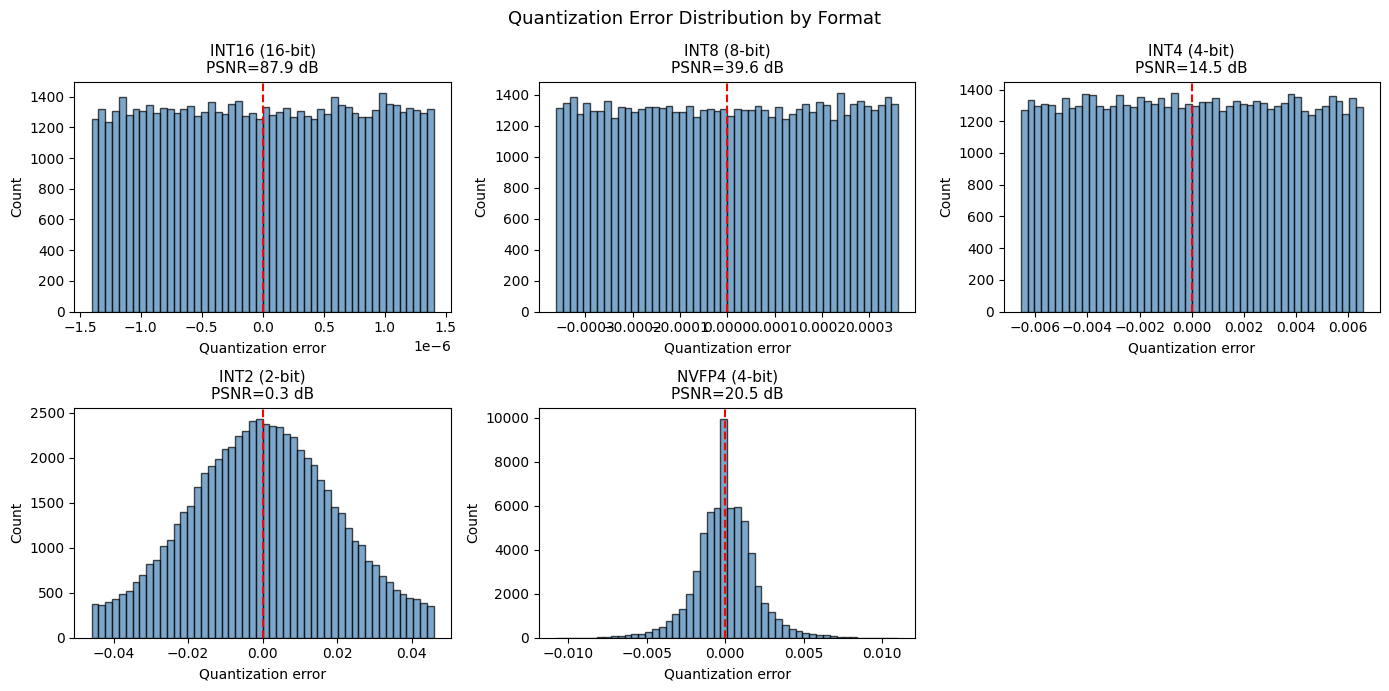

In [3]:
def quantize_symmetric(x: torch.Tensor, bits: int) -> tuple:
    """Symmetric integer quantization: zero point = 0."""
    qmax = 2 ** (bits - 1) - 1  # e.g., 127 for INT8
    scale = x.abs().max() / qmax
    q = torch.clamp(torch.round(x / scale), -qmax, qmax).to(torch.int8 if bits <= 8 else torch.int16)
    return q, scale

def dequantize_symmetric(q: torch.Tensor, scale: float) -> torch.Tensor:
    """Reverse integer quantization."""
    return q.float() * scale

# NVFP4 E2M1 representable magnitudes — non-uniform, denser near zero
_E2M1 = torch.tensor([0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0])

def quantize_nvfp4(x: torch.Tensor, block_size: int = 16) -> torch.Tensor:
    """Simulate NVFP4 (E2M1) with per-block FP8 scale factors (microscaling)."""
    flat = x.flatten()
    n = flat.numel()
    pad = (block_size - n % block_size) % block_size
    padded = torch.cat([flat, torch.zeros(pad)]).reshape(-1, block_size)
    block_max = padded.abs().amax(dim=1, keepdim=True).clamp(min=1e-12)
    scales = block_max / 6.0  # 6.0 is max E2M1 magnitude
    scaled = (padded / scales).abs()
    signs = torch.sign(padded / scales)
    diffs = (scaled.unsqueeze(-1) - _E2M1).abs()
    idx = diffs.argmin(dim=-1)
    dq = signs * _E2M1[idx] * scales
    return dq.flatten()[:n].reshape(x.shape)

# Simulate a weight tensor from a real model layer
torch.manual_seed(42)
weights = torch.randn(256, 256) * 0.02  # Typical weight magnitude

print("Quantization error analysis")
print(f"Original weights: min={weights.min():.4f}, max={weights.max():.4f}, std={weights.std():.4f}")
print()
print(f"{'Format':>8} {'Bits':>5} {'Max Error':>12} {'MSE':>14} {'PSNR (dB)':>12}")
print("-" * 60)

formats = [
    ('INT16', 16, 'int'),
    ('INT8',   8, 'int'),
    ('INT4',   4, 'int'),
    ('INT2',   2, 'int'),
    ('NVFP4',  4, 'nvfp4'),  # 4-bit floating-point with block scaling
]

results = {}
for fmt, bits, kind in formats:
    if kind == 'int':
        q, scale = quantize_symmetric(weights, bits)
        dq = dequantize_symmetric(q, scale)
    else:  # nvfp4
        dq = quantize_nvfp4(weights, block_size=16)
    error = (weights - dq).abs()
    mse = ((weights - dq) ** 2).mean().item()
    signal_power = (weights ** 2).mean().item()
    psnr = 10 * np.log10(signal_power / mse) if mse > 0 else float('inf')
    results[fmt] = {'bits': bits, 'dq': dq, 'max_error': error.max().item(), 'mse': mse, 'psnr': psnr}
    print(f"{fmt:>8} {bits:>5} {error.max():>12.6f} {mse:>14.8f} {psnr:>12.2f}")

# Visualize quantization error distribution — one subplot per format
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flat

for ax, (fmt, bits, _) in zip(axes, formats):
    error = (weights - results[fmt]['dq']).flatten().numpy()
    ax.hist(error, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--')
    ax.set_title(f'{fmt} ({bits}-bit)\nPSNR={results[fmt]["psnr"]:.1f} dB', fontsize=11)
    ax.set_xlabel('Quantization error')
    ax.set_ylabel('Count')

# Hide unused subplot
axes[5].axis('off')

plt.suptitle('Quantization Error Distribution by Format', fontsize=13)
plt.tight_layout()
plt.show()

## Part 2: Memory Savings and Throughput Impact

Each bit reduction in precision directly reduces memory:
- FP16 → INT8: 2× smaller weights (50% memory reduction)
- FP16 → INT4: 4× smaller weights (75% memory reduction)

Smaller weights = less memory to load per token = higher decode throughput (recall: decode is memory-bound).

Additionally, Hopper GPUs have FP8 Tensor Cores that compute twice as fast as FP16 Tensor Cores — so FP8 gives both a memory AND compute speedup.

Model memory footprint (GB) by format:
       Model     FP32    BF16    FP16     FP8    INT8    INT4   NVFP4
--------------------------------------------------------------------
7B model:        28G     14G     14G      7G      7G      4G      4G
13B model:        52G     26G     26G     13G     13G      6G      6G
30B model:         *2     60G     60G     30G     30G     15G     15G
70B model:         *4      *2      *2     70G     70G     35G     35G
236B model:        *12      *6      *6      *3      *3      *2      *2
671B model:        *34     *17     *17      *9      *9      *5      *5

*N = needs N H100 GPUs (80GB each) just for weights


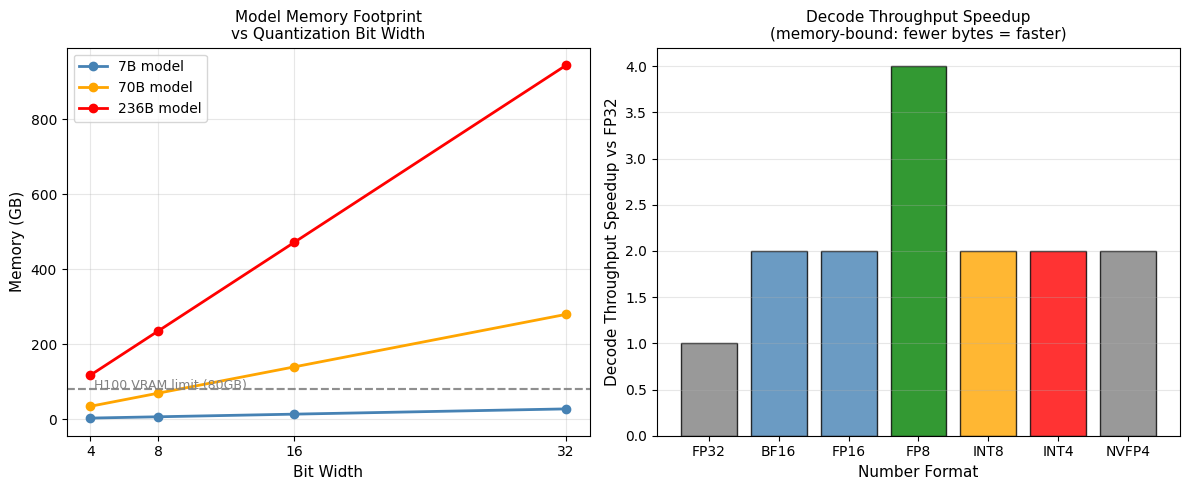

In [4]:
# Model the memory and throughput impact of quantization

model_sizes_b = [7, 13, 30, 70, 236, 671]  # Billion parameters
formats = {
    'FP32': {'bytes': 4, 'speedup': 1.0},
    'BF16': {'bytes': 2, 'speedup': 2.0},
    'FP16': {'bytes': 2, 'speedup': 2.0},
    'FP8':  {'bytes': 1, 'speedup': 4.0},   # 2x memory + 2x compute on Hopper
    'INT8': {'bytes': 1, 'speedup': 2.0},   # 2x memory, similar compute
    'INT4': {'bytes': 0.5, 'speedup': 2.0}, # 4x memory, similar compute
    'NVFP4': {'bytes': 0.5, 'speedup': 2.0}
}

H100_VRAM_GB = 80  # H100 SXM

print("Model memory footprint (GB) by format:")
print(f"{'Model':>12} ", end='')
for fmt in formats:
    print(f"{fmt:>8}", end='')
print()
print("-" * (12 + 8 * len(formats)))

for size_b in model_sizes_b:
    print(f"{size_b}B model:   ", end='')
    for fmt, props in formats.items():
        gb = size_b * 1e9 * props['bytes'] / 1e9
        gpus_needed = max(1, int(np.ceil(gb / H100_VRAM_GB)))
        marker = f"*{gpus_needed}" if gpus_needed > 1 else f"{gb:.0f}G"
        print(f"{marker:>8}", end='')
    print()

print()
print("*N = needs N H100 GPUs (80GB each) just for weights")

# Plot memory vs bit width
bit_widths = [32, 16, 8, 4]
bytes_per = [4, 2, 1, 0.5]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for size_b, color in zip([7, 70, 236], ['steelblue', 'orange', 'red']):
    gb_values = [size_b * 1e9 * bpw / 1e9 for bpw in bytes_per]
    ax1.plot(bit_widths, gb_values, 'o-', color=color, linewidth=2, label=f'{size_b}B model')
    ax1.axhline(y=H100_VRAM_GB, color='gray', linestyle='--', alpha=0.5)

ax1.set_xlabel('Bit Width', fontsize=11)
ax1.set_ylabel('Memory (GB)', fontsize=11)
ax1.set_title('Model Memory Footprint\nvs Quantization Bit Width', fontsize=11)
ax1.set_xticks(bit_widths)
ax1.legend()
ax1.text(4.2, H100_VRAM_GB + 2, 'H100 VRAM limit (80GB)', fontsize=9, color='gray')
ax1.grid(True, alpha=0.3)

# Decode throughput speedup
speedups = [f['speedup'] for f in formats.values()]
ax2.bar(list(formats.keys()), speedups, color=['gray', 'steelblue', 'steelblue', 'green', 'orange', 'red'],
        alpha=0.8, edgecolor='black')
ax2.set_xlabel('Number Format', fontsize=11)
ax2.set_ylabel('Decode Throughput Speedup vs FP32', fontsize=11)
ax2.set_title('Decode Throughput Speedup\n(memory-bound: fewer bytes = faster)', fontsize=11)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Part 3: FP8 — The Current Sweet Spot

FP8 is the current production sweet spot for inference on modern hardware:
- **H100/B200 have native FP8 Tensor Cores** — 2× faster GEMM than FP16
- **Half the memory** of FP16
- **Two variants:** E4M3 (4 exponent bits, 3 mantissa) for weights; E5M2 (5 exp, 2 mantissa) for activations
- **Negligible quality loss** with good calibration

FP8 combines a compute AND memory speedup — unique among quantization formats.

In [ ]:
# Simulate FP8 quantization and compare to FP16 and INT8

def simulate_fp8_e4m3(x: torch.Tensor) -> torch.Tensor:
    """
    Approximate FP8 E4M3 quantization.
    Max value: 448, 3 mantissa bits -> ~8 levels between consecutive exponents.
    """
    FP8_MAX = 448.0
    # Scale to fit in FP8 range
    scale = x.abs().max() / FP8_MAX
    x_scaled = x / scale
    # Quantize mantissa (3 bits = 8 levels)
    x_clamped = torch.clamp(x_scaled, -FP8_MAX, FP8_MAX)
    # Simulate 3-bit mantissa rounding
    # For each value, round to nearest representable FP8 value
    sign = torch.sign(x_clamped)
    abs_val = x_clamped.abs()
    # FP8 E4M3 has 8 levels of mantissa
    mantissa_levels = 8  # 2^3
    # Round to nearest power-of-2-aligned step
    log2_val = torch.log2(abs_val.clamp(min=1e-10))
    exp = torch.floor(log2_val)
    frac = abs_val / (2 ** exp)
    frac_quantized = torch.round(frac * mantissa_levels) / mantissa_levels
    quantized = sign * frac_quantized * (2 ** exp) * scale
    return quantized

torch.manual_seed(42)
# Simulate a weight tensor (typical LLM weight distribution)
weights = torch.randn(1000) * 0.05

# INT8 quantization
q8, s8 = quantize_symmetric(weights, 8)
dq_int8 = dequantize_symmetric(q8, s8)

# FP8 E4M3 (approximate)
dq_fp8 = simulate_fp8_e4m3(weights)

# FP4 (INT4)
q4, s4 = quantize_symmetric(weights, 4)
dq_int4 = dequantize_symmetric(q4, s4)

formats_results = {
    'FP16 (no quant)': weights,
    'INT8': dq_int8,
    'FP8 E4M3': dq_fp8,
    'INT4': dq_int4
}

print("Format comparison (1000 random weights):")
print(f"{'Format':<20} {'MSE':>15} {'Max Error':>12} {'Memory vs FP16':>15}")
print("-" * 65)
for name, dq in formats_results.items():
    mse = ((weights - dq) ** 2).mean().item()
    max_err = (weights - dq).abs().max().item()
    bits = {'FP16 (no quant)': 16, 'INT8': 8, 'FP8 E4M3': 8, 'INT4': 4}[name]
    mem_ratio = f"{bits/16:.2f}x"
    print(f"{name:<20} {mse:>15.8f} {max_err:>12.6f} {mem_ratio:>15}")

print()
print("FP8 vs INT8: similar memory, but FP8 has native Tensor Core support")
print("on H100/B200 for 2x faster GEMM. This is why FP8 is the preferred format.")

Format comparison (1000 random weights):
Format                           MSE    Max Error  Memory vs FP16
-----------------------------------------------------------------
FP16 (no quant)           0.00000000     0.000000           1.00x
INT8                      0.00000012     0.000610           0.50x
FP8 E4M3                  0.00000186     0.005524           0.50x
INT4                      0.00003776     0.011069           0.25x

FP8 vs INT8: similar memory, but FP8 has native Tensor Core support
on H100/B200 for 2x faster GEMM. This is why FP8 is the preferred format.


## Part 4: NVFP4 — Blackwell's Microscaled 4-bit Floating Point

INT4 quantization packs weights into 4 bits, but those 4 bits are integers — no exponent, no floating-point dynamic range. For weights with large variation across channels, INT4 struggles without per-group scaling.

NVIDIA's Blackwell architecture (B200, GB200, GB10) introduces **NVFP4**, a native 4-bit floating-point format with **microscaling** (also called block scaling or MX scaling):

- **E2M1 encoding:** 1 sign bit, 2 exponent bits, 1 mantissa bit — 4 representable magnitudes per sign: {0, 0.5, 1, 1.5, 2, 3, 4, 6}
- **Block scale factor:** Every block of 16 or 32 values shares an FP8 scale factor. This recovers dynamic range that the tiny 4-bit format loses.
- **Effective bits:** 4 bits per weight + amortized scale overhead (8 bits / 16 values = 0.5 bits) ≈ 4.5 bits effective

The key advantage over INT4: floating-point representation handles outliers more gracefully because the exponent bits provide non-uniform spacing (denser near zero, sparser for large values).

$$\text{NVFP4 value} = \text{block\_scale} \times (-1)^{s} \times \text{E2M1\_decode}(\text{exp}, \text{mantissa})$$

Blackwell Tensor Cores execute FP4 GEMMs natively at **2\times$$ the FP8 throughput** — theoretically ~8 petaFLOPS on B200 vs ~4 petaFLOPS in FP8.

Format                           MSE    Max Error  Eff. bits   70B Memory
------------------------------------------------------------------------
FP16 (baseline)           0.00000000     0.000000       16.0      140.0 GB
INT8                      0.00000019     0.000754        8.0       70.0 GB
FP8 E4M3                  0.00000170     0.006794        8.0       70.0 GB
INT4 (global)             0.00006252     0.013688        4.0       35.0 GB
NVFP4 (blk=16)            0.00002179     0.023784        4.5       39.4 GB
NVFP4 (blk=32)            0.00002454     0.023784        4.2       37.2 GB

NVFP4 with block_size=16 achieves lower error than global INT4
because microscaling recovers per-block dynamic range.
Effective bits: 4 + 8/block_size (scale overhead).



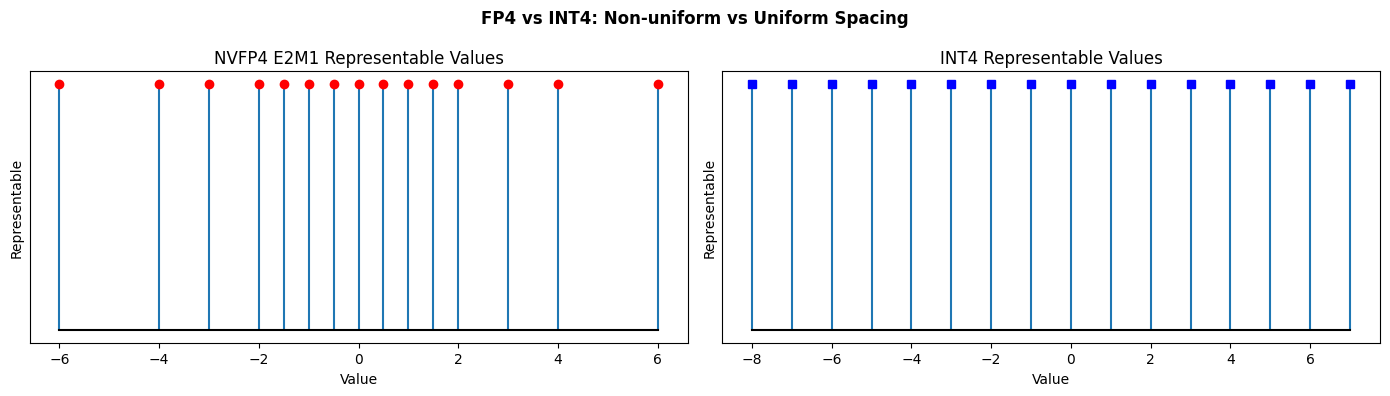

FP4 clusters levels near zero where most weights live.
INT4 wastes levels on large magnitudes that rarely occur.


In [6]:
# Simulate NVFP4 (E2M1) with microscaling

# E2M1 representable magnitudes (unsigned)
# exp=0,m=0 -> 0; exp=0,m=1 -> 0.5; exp=1,m=0 -> 1; exp=1,m=1 -> 1.5
# exp=2,m=0 -> 2; exp=2,m=1 -> 3; exp=3,m=0 -> 4; exp=3,m=1 -> 6
E2M1_VALUES = np.array([0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0])
# With sign: 15 distinct values (zero is shared) in [-6, 6]

def quantize_nvfp4_block(block: torch.Tensor, block_size: int = 16) -> tuple:
    """Quantize a tensor using NVFP4 E2M1 with per-block FP8 scale factors."""
    n = block.numel()
    padded = torch.zeros((n + block_size - 1) // block_size * block_size)
    padded[:n] = block
    padded = padded.reshape(-1, block_size)
    
    # Per-block scale: map block max to E2M1 max (6.0)
    block_max = padded.abs().amax(dim=1, keepdim=True).clamp(min=1e-12)
    scales = block_max / 6.0
    
    scaled = padded / scales
    
    # Map each value to nearest E2M1 representable value
    signs = torch.sign(scaled)
    abs_scaled = scaled.abs()
    
    e2m1 = torch.tensor(E2M1_VALUES)
    # Find nearest E2M1 value for each element
    diffs = (abs_scaled.unsqueeze(-1) - e2m1.unsqueeze(0).unsqueeze(0)).abs()
    indices = diffs.argmin(dim=-1)
    quantized_abs = e2m1[indices]
    
    dequantized = signs * quantized_abs * scales
    return dequantized[:, :block.numel() - (padded.shape[0]-1)*block_size].reshape(-1)[:n], scales

torch.manual_seed(42)
weights = torch.randn(4096) * 0.05

# Compare all formats including NVFP4
q8, s8 = quantize_symmetric(weights, 8)
dq_int8 = dequantize_symmetric(q8, s8)
dq_fp8 = simulate_fp8_e4m3(weights)
q4, s4 = quantize_symmetric(weights, 4)
dq_int4 = dequantize_symmetric(q4, s4)

# NVFP4 with different block sizes
dq_nvfp4_16, _ = quantize_nvfp4_block(weights, block_size=16)
dq_nvfp4_32, _ = quantize_nvfp4_block(weights, block_size=32)

all_formats = {
    'FP16 (baseline)': (weights, 16),
    'INT8':            (dq_int8, 8),
    'FP8 E4M3':        (dq_fp8, 8),
    'INT4 (global)':   (dq_int4, 4),
    'NVFP4 (blk=16)':  (dq_nvfp4_16, 4.5),
    'NVFP4 (blk=32)':  (dq_nvfp4_32, 4.25),
}

print(f"{'Format':<20} {'MSE':>15} {'Max Error':>12} {'Eff. bits':>10} {'70B Memory':>12}")
print("-" * 72)
for name, (dq, bits) in all_formats.items():
    mse = ((weights - dq) ** 2).mean().item()
    max_err = (weights - dq).abs().max().item()
    mem_gb = 70e9 * bits / 8 / 1e9
    print(f"{name:<20} {mse:>15.8f} {max_err:>12.6f} {bits:>10.1f} {mem_gb:>10.1f} GB")

print()
print("NVFP4 with block_size=16 achieves lower error than global INT4")
print("because microscaling recovers per-block dynamic range.")
print("Effective bits: 4 + 8/block_size (scale overhead).")
print()

# Visualize quantization grid
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# E2M1 representable values (non-uniform spacing)
signed_vals = np.concatenate([-E2M1_VALUES[::-1], E2M1_VALUES[1:]])
axes[0].stem(signed_vals, np.ones_like(signed_vals), markerfmt='ro', basefmt='k-')
axes[0].set_title('NVFP4 E2M1 Representable Values')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Representable')
axes[0].set_yticks([])

# INT4 representable values (uniform spacing)
int4_vals = np.arange(-8, 8)
axes[1].stem(int4_vals, np.ones_like(int4_vals), markerfmt='bs', basefmt='k-')
axes[1].set_title('INT4 Representable Values')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Representable')
axes[1].set_yticks([])

plt.suptitle('FP4 vs INT4: Non-uniform vs Uniform Spacing', fontweight='bold')
plt.tight_layout()
plt.show()
print("FP4 clusters levels near zero where most weights live.")
print("INT4 wastes levels on large magnitudes that rarely occur.")

## Try These Experiments

1. **Quantization with outliers:** Add a few extreme outlier values (e.g., 10 values of ±100) to the weight tensor. How does this affect INT8 quantization error for the majority of weights? This is why AWQ and GPTQ (Day 14) use per-group quantization.

2. **Memory + throughput compound model:** Build a model that takes (bits, param_count, memory_bandwidth_gbs) as inputs and outputs expected decode throughput (tokens/sec). Show that FP8 provides ~4x more throughput than FP32 on H100.

3. **NVFP4 block size sweep:** Try block sizes of 4, 8, 16, 32, and 64 for NVFP4. Plot MSE vs effective bits (4 + 8/block_size). At what block size does NVFP4 match INT8 quality?

4. **How many GPUs needed:** For DeepSeek V3 (671B parameters), calculate the minimum GPU count at each precision format (FP16, INT8, INT4) assuming H100 GPUs with 80GB VRAM. Account for 20% KV cache overhead.

## Key Takeaways

- Quantization reduces bits per weight, shrinking model memory footprint and boosting decode throughput (memory-bound).
- **FP8 is the current sweet spot:** native H100/B200 Tensor Core support gives both memory and compute speedups.
- INT4 provides extreme compression (70B fits on one H100) but requires careful quantization algorithms to maintain quality.
- The fundamental tradeoff: fewer bits = lower accuracy, especially for outlier weights that are important for model quality.
- **NVFP4** on Blackwell doubles FP8 throughput again, with microscaling to preserve quality at 4 bits.
- **What's next:** Day 14 — Quantization algorithms (GPTQ, AWQ, SmoothQuant) — how to quantize while minimizing accuracy loss.

## References
- *Inference Engineering* Ch 5.1.1 — Quantization: Number Formats